
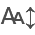

In [1]:
import pandas as pd
import os
import numpy as np
from copy import deepcopy

import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import make_scorer, precision_score, f1_score, fbeta_score
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.callbacks import EarlyStopping
import shap
import random
from sklearn.utils import class_weight

from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

In [2]:
processed_data_input_path = os.path.join(os.getcwd(), '..', 'data', 'data_processed')
figures_path = os.path.join(os.getcwd(), '..', 'data', 'visualizations')

ustawienie ziarna globalnie

In [3]:
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

In [4]:
df = pd.read_csv(os.path.join(processed_data_input_path, 'initial_features_selected.csv'))

df = df.set_index('Unnamed: 0')
df.index.name = None
df

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [5]:
benchmark_cols = [
    'season',
    'gameweek',
    'team',
    'opponent',
    'home_game',
    'goals_scored',
    'goals_conceded',
    'prob_unexpected_result',
    'elo_unexpected_result',
    'win_probability',
    'draw_probability',
    'not_loss_probability',
    'win_odds',
    'draw_odds',
    'loss_odds'
]
df_benchmark = df[benchmark_cols].copy()
benchmark_cols.remove('prob_unexpected_result')
df = df.drop(columns=benchmark_cols)

df

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


Podział na zbiory - treningowy, walidacyjny, testowy (70/15/15)

In [6]:
n = len(df)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

# Skalowanie danych
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df.iloc[:,:-4]), columns=df.columns[:-4])
df_scaled.index = df.index
                         
df_scaled = pd.concat([df_scaled, df.iloc[:,-4:]], axis=1)

X_train = df_scaled.iloc[:train_end, :-1]
y_train = df_scaled.iloc[:train_end, -1]

X_val = df_scaled.iloc[train_end:val_end, :-1]
y_val = df_scaled.iloc[train_end:val_end, -1]

X_trainval = df_scaled.iloc[:val_end, :-1]
y_trainval = df_scaled.iloc[:val_end, -1]

X_test = df_scaled.iloc[val_end:, :-1]
y_test = df_scaled.iloc[val_end:, -1]   
# X_train = df.iloc[:train_end, :-1]
# y_train = df.iloc[:train_end, -1]

# X_val = df.iloc[train_end:val_end, :-1]
# y_val = df.iloc[train_end:val_end, -1]

# X_trainval = df.iloc[:val_end, :-1]
# y_trainval = df.iloc[:val_end, -1]

# X_test = df.iloc[val_end:, :-1]
# y_test = df.iloc[val_end:, -1]   

# df_trainval = deepcopy(df_features.iloc[:val_end])
# df_trainval['match_id'] = df_trainval.index // 2


X_train

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


utworzenie wstępnego modelu do doboru architektury

In [7]:
def create_model1(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

def create_model2(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

def create_model3(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model


In [8]:
clf1 = KerasClassifier(
    model=create_model1, 
    input_dim=X_train.shape[1],  # <-- przekazujesz input_dim jako parametr modelu
    epochs=50, 
    batch_size=32,
    verbose=0, 
    shuffle=False, 
    random_state=42,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
    )
# clf = create_model(X_train)

clf1.fit(X_train, y_train)

KerasClassifier(
	model=<function create_model1 at 0x000002654B9F0680>
	build_fn=None
	warm_start=False
	random_state=42
	optimizer=<keras.src.optimizers.adam.Adam object at 0x000002654B62E810>
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=False
	run_eagerly=False
	epochs=50
	input_dim=71
	class_weight=None
)

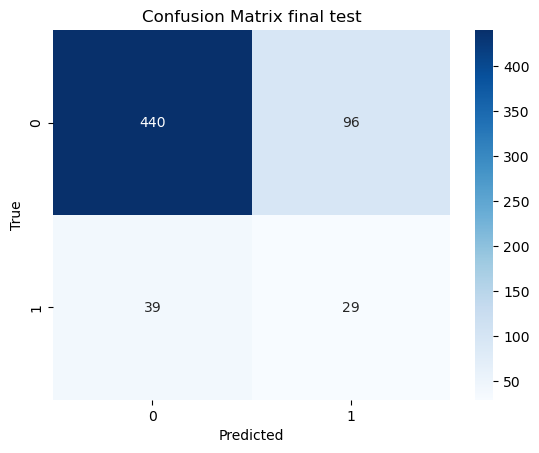

              precision    recall  f1-score   support

           0      0.919     0.821     0.867       536
           1      0.232     0.426     0.301        68

    accuracy                          0.776       604
   macro avg      0.575     0.624     0.584       604
weighted avg      0.841     0.776     0.803       604

ROC AUC: 0.766


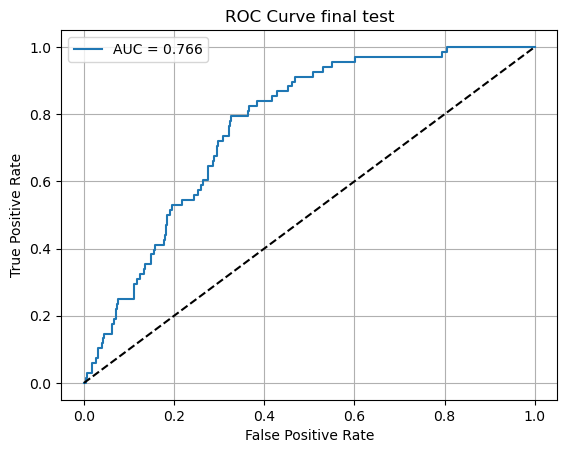

In [9]:
y_prob1 = clf1.predict_proba(X_val)[:, 1]
y_pred1 = (y_prob1 >= 0.2).astype(int)

cm = confusion_matrix(y_val, y_pred1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix final test')
plt.show()

# 2. Classification report
print(classification_report(y_val, y_pred1, digits=3))

# 3. ROC AUC
auc_score = roc_auc_score(y_val, y_prob1)
print(f"ROC AUC: {auc_score:.3f}")

# 4. Wykres ROC
fpr, tpr, thresholds = roc_curve(y_val, y_prob1)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve final test')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
def create_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model


Sprawdzenie istotności cech korzystając ze zbioru walidacyjnego

PermutationExplainer explainer: 605it [29:29,  2.93s/it]                            


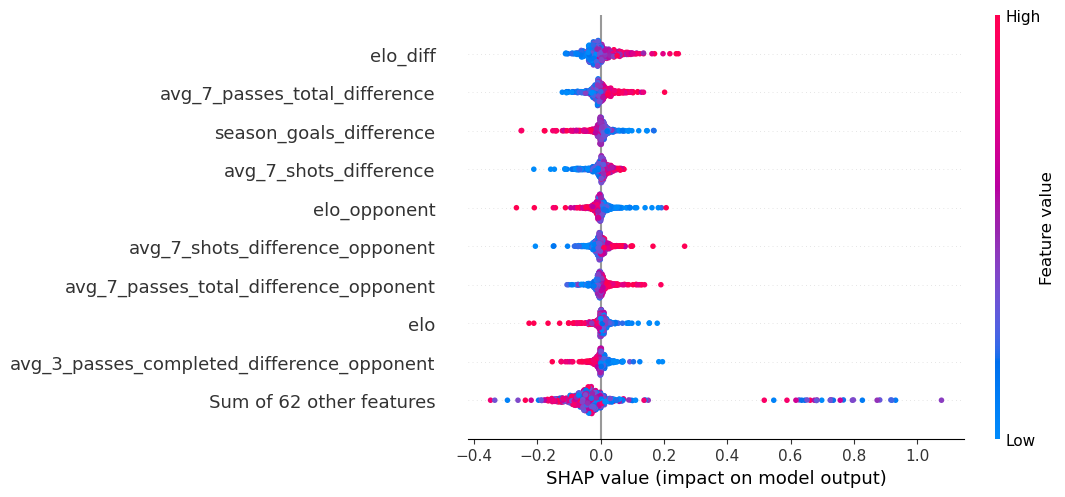

In [11]:
explainer = shap.Explainer(clf1.predict, X_val)  # clf to Twoja sieć
shap_values = explainer(X_val)

shap.plots.beeswarm(shap_values)

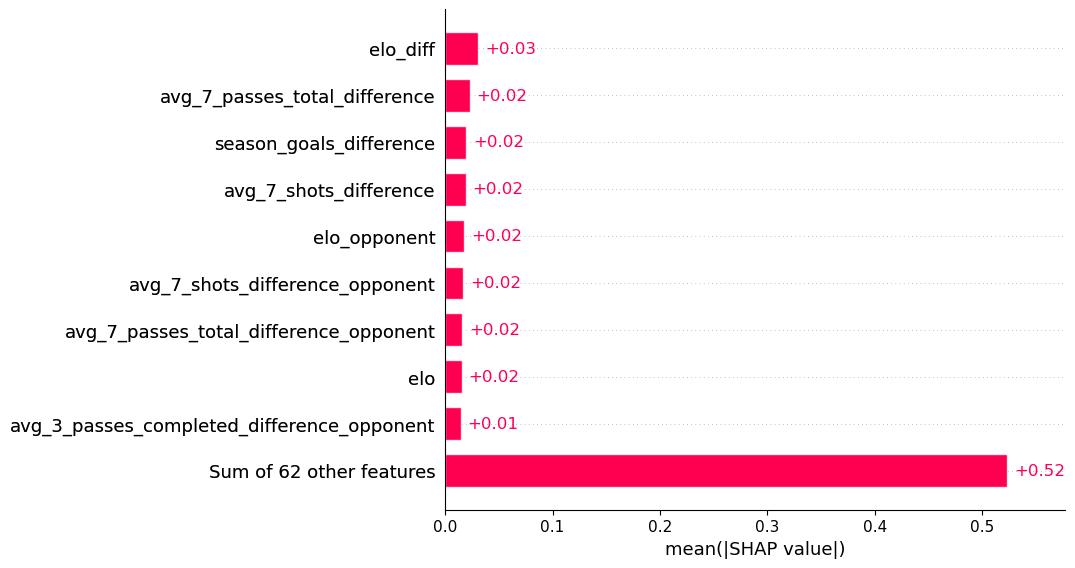

In [ ]:
explainer = shap.Explainer(clf1.predict, X_val)  # clf to Twoja sieć

Krosswalidacja modeli tworzonych na podstawie n najistotniejszych cech wg SHAP w celu selekcji cech

In [18]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.base import clone


def model_CV(X, y, n_split=5):
    tscv = TimeSeriesSplit(n_splits=n_split)
    scores = []
    i = 1
    for train_idx, val_idx in tscv.split(X.index):
        print(f"fold {i}")
        # Podział danych
        X_train_CV, X_val_CV = X.iloc[train_idx], X.iloc[val_idx]
        y_train_CV, y_val_CV = y.iloc[train_idx], y.iloc[val_idx]

        # Opakowanie modelu
        clf_fold = KerasClassifier(
            model=create_model, 
            input_dim=X_train_CV.shape[1],  # <-- przekazujesz input_dim jako parametr modelu
            epochs=10, 
            batch_size=32,
            verbose=0, 
            shuffle=False, 
            random_state=42)
        # clf = create_model(X_train)

        # 🏋️‍♂️ Trening
        clf_fold.fit(X_train_CV, y_train_CV, epochs=20, batch_size=32, verbose=0)

        # 🔍 Predykcja i metryka
        y_prob_CV = clf_fold.predict_proba(X_val_CV)[:, 1]
        y_pred_CV = (y_prob_CV > 0.2).astype(int)  
        
        score = f1_score(y_val_CV, y_pred_CV)
        
        scores.append(score)
        i += 1
    return pd.Series(scores)

def shap_feature_selection(X, y, model, shap_vals, steps, scoring='f1'):

    mean_abs = np.abs(shap_vals.values).mean(axis=0)
    order = np.argsort(mean_abs)[::-1]  # od najważniejszych

    mean_shap_df = pd.DataFrame(data={
        'feature': shap_vals.feature_names,
        'mean_abs_shap': mean_abs
    })

    results = []
    for k in steps:
        print(f"{k} features")
        keep_idx = order[:k]
        X_sel = X.iloc[:, keep_idx]

        scores = model_CV(X_sel, y, n_split=5)
        results.append({
            "n_features": k,
            "mean_score": scores.mean(),
            "std_score": scores.std(),
            "max_score": scores.max(),
            "features": list(X_sel.columns)
        })
        print(scores.mean(), scores.std(), scores.max())
    return results, mean_shap_df
n_features = [28, 30, 32, 35, 38, 40, 45, 50, len(X_val.columns)]
results, mean_shap_df = shap_feature_selection(X_train, y_train, clf1, shap_values, n_features)

28 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.29900153423389486 0.047166109910896536 0.34806629834254144
30 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.28439877086258075 0.04747545254727636 0.35170603674540685
32 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.305021642470675 0.04100817163728671 0.3622448979591837
35 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.2737274268182356 0.0730106649240992 0.3569553805774278
38 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.2959791728306615 0.05869809044945813 0.3670212765957447
40 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.29229679197996533 0.06390951728610884 0.3770491803278688
45 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.2932359501266296 0.049013385344957694 0.34173669467787116
50 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.27970699537529653 0.05727099102821561 0.32558139534883723
71 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.28207996431890575 0.05276482498037228 0.3224181360201511


In [25]:
len(results[5]['features'])

40

In [11]:
cols = results[5]['features']
cols

NameError: name 'results' is not defined

In [12]:
cols = ['elo_diff',
 'avg_7_passes_total_difference',
 'season_goals_difference',
 'avg_7_shots_difference',
 'elo_opponent',
 'avg_7_shots_difference_opponent',
 'avg_7_passes_total_difference_opponent',
 'elo',
 'avg_3_passes_completed_difference_opponent',
 'avg_3_passes_completed_difference',
 'avg_3_shots_difference_opponent',
 'league_position',
 'avg_7_corners_difference',
 'avg_3_shots_difference',
 'avg_5_h/a_xG_difference_opponent',
 'league_position_opponent',
 'avg_7_goals_difference',
 'last_1_shots_difference_opponent',
 'avg_5_h/a_goals_difference',
 'avg_5_h/a_xG_difference',
 'avg_5_h/a_goals_difference_opponent',
 'avg_5_h/a_shots_difference',
 'avg_5_h/a_shots_difference_opponent',
 'season_goals_difference_opponent',
 'last_1_shots_difference',
 'last_1_goals_difference_opponent',
 'last_1_xG_difference_opponent',
 'avg_7_goals_difference_opponent',
 'avg_3_xG_difference_opponent',
 'avg_5_h/a_shots_on_target_difference_opponent',
 'last_1_xG_difference',
 'avg_3_shots_on_target_difference_opponent',
 'avg_7_xG_difference_opponent',
 'avg_3_corners_difference_opponent',
 'avg_3_points',
 'avg_5_h/a_shots_on_target_difference',
 'avg_5_h/a_crosses_difference_opponent',
 'avg_7_crosses_difference_opponent',
 'avg_7_corners_difference_opponent',
 'avg_5_h/a_passes_completed_difference_opponent']

In [13]:
X_train2 = X_train[cols]
X_val2 = X_val[cols]
X_test2 = X_test[cols]

Sprawdzenie działania modelu po selekcji cech

In [14]:
clf2 = KerasClassifier(
    model=create_model, 
    input_dim=X_train2.shape[1],  # <-- przekazujesz input_dim jako parametr modelu
    epochs=50, 
    batch_size=32,
    verbose=0, 
    shuffle=False, 
    random_state=42)
# clf = create_model(X_train)
clf2.fit(X_train2, y_train)


KerasClassifier(
	model=<function create_model at 0x000002654B6722A0>
	build_fn=None
	warm_start=False
	random_state=42
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=False
	run_eagerly=False
	epochs=50
	input_dim=40
	class_weight=None
)

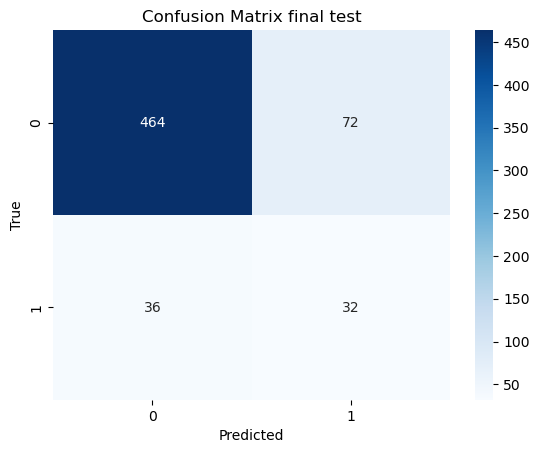

              precision    recall  f1-score   support

           0      0.928     0.866     0.896       536
           1      0.308     0.471     0.372        68

    accuracy                          0.821       604
   macro avg      0.618     0.668     0.634       604
weighted avg      0.858     0.821     0.837       604

ROC AUC: 0.781


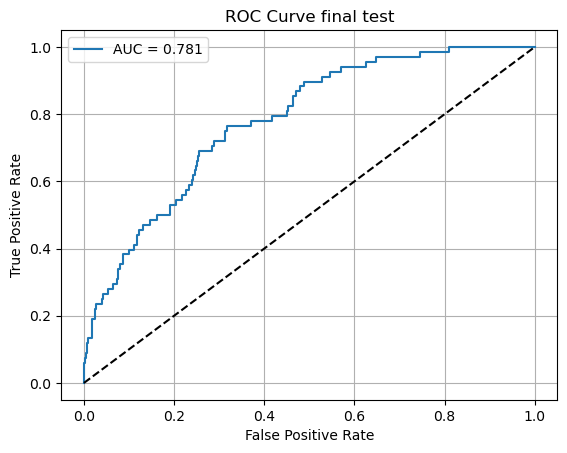

In [16]:
y_prob2 = clf2.predict_proba(X_val2)[:, 1]
y_pred2 = (y_prob2 >= 0.2).astype(int)

cm = confusion_matrix(y_val, y_pred2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix final test')
plt.show()

# 2. Classification report
print(classification_report(y_val, y_pred2, digits=3))

# 3. ROC AUC
auc_score = roc_auc_score(y_val, y_prob2)
print(f"ROC AUC: {auc_score:.3f}")

# 4. Wykres ROC
fpr, tpr, thresholds = roc_curve(y_val, y_prob2)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve final test')
plt.legend()
plt.grid(True)
plt.show()

szukanie optymalnych parametrów sieci

In [135]:
f05_scorer = make_scorer(fbeta_score, beta=0.4, pos_label=1)

In [140]:
def create_model_optimized(input_dim, dropout_rate, dense1_units, dense2_units, dense3_units, activation):
    model = Sequential([
        # Input(shape=(input_dim,)),
        # Dense(dense1_units, activation='relu'),
        # Dropout(dropout_rate),
        # Dense(dense2_units, activation='relu'),
        # Dropout(dropout_rate),
        # Dense(1, activation='sigmoid')
        Input(shape=(input_dim,)),
        Dense(dense1_units, activation=activation),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(dense2_units, activation=activation),
        Dropout(dropout_rate),
        Dense(dense3_units, activation=activation),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model


In [ ]:
# early_stop = EarlyStopping(
#     monitor="val_loss",  # lub 'loss' jeśli nie używasz walidacji
#     patience=5,
#     restore_best_weights=True,
#     verbose=1
# )

clf_opt = KerasClassifier(
    model=create_model_optimized, 
    verbose=0, 
    shuffle=False, 
    random_state=42,
    # fit__callbacks=[early_stop],
    # fit__validation_split=0.2
)

param_dist = {
    "batch_size": [16, 32, 64],
    "epochs": [30, 50, 70],
    "model__input_dim": [X_train2.shape[1]],  # nie tuninguje się
    "model__dropout_rate": [0.2, 0.3, 0.4, 0.5],  # musisz dodać dropout_rate jako parametr create_model
    "model__dense1_units": [128, 256, 512],
    "model__dense2_units": [32, 64, 128],
    "model__dense3_units": [16, 32, 64],
    "model__activation": ['relu', 'selu', 'elu']
}

search = RandomizedSearchCV(clf_opt, param_distributions=param_dist, cv=5, scoring=f05_scorer, n_iter=100, n_jobs=-1)
search.fit(X_train2, y_train)

c:\Users\gcich\anaconda3\envs\ADWNOZ\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=KerasClassifier(model=<function create_model_optimized at 0x000001A28CC68180>, random_state=42, shuffle=False, verbose=0),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'batch_size': [16, 32, 64],
                                        'epochs': [30, 50, 70],
                                        'model__activation': ['relu', 'selu',
                                                              'elu'],
                                        'model__dense1_units': [128, 256, 512],
                                        'model__dense2_units': [32, 64, 128],
                                        'model__dense3_units': [16, 32, 64],
                                        'model__dropout_rate': [0.2, 0.3, 0.4,
                                                                0.5],
                                        'model__input_dim': [40]},
                   scoring=make_scorer(fbeta_score, response_method='predict', beta=0.4, pos_label=1))

In [160]:
print("Najlepsze parametry:", search.best_params_)
print("Najlepszy wynik Precision:", search.best_score_)

Najlepsze parametry: {'model__input_dim': 40, 'model__dropout_rate': 0.2, 'model__dense3_units': 32, 'model__dense2_units': 128, 'model__dense1_units': 256, 'model__activation': 'relu', 'epochs': 50, 'batch_size': 64}
Najlepszy wynik Precision: 0.2263646301779402


In [17]:

def create_model_best(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

clf_best = KerasClassifier(
    model=create_model_best, 
    input_dim=X_train2.shape[1],
    verbose=0, 
    shuffle=False, 
    random_state=42,
    epochs=50, 
    batch_size=32
    # fit__callbacks=[early_stop],
    # fit__validation_split=0.2
)
clf_best.fit(X_train2, y_train)


KerasClassifier(
	model=<function create_model_best at 0x0000026554338CC0>
	build_fn=None
	warm_start=False
	random_state=42
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=False
	run_eagerly=False
	epochs=50
	input_dim=40
	class_weight=None
)

dobór optymalnego progu klasyfikacji

ROC AUC: 0.781


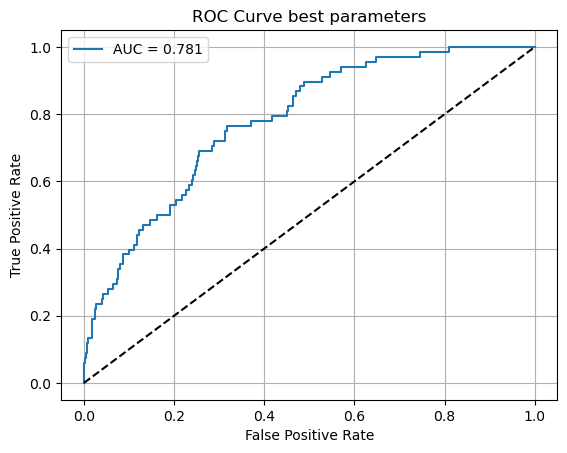


Threshold checked: 0.2



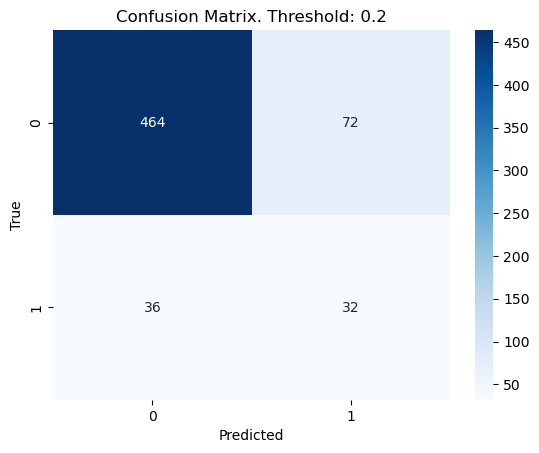

              precision    recall  f1-score   support

           0      0.928     0.866     0.896       536
           1      0.308     0.471     0.372        68

    accuracy                          0.821       604
   macro avg      0.618     0.668     0.634       604
weighted avg      0.858     0.821     0.837       604


Threshold checked: 0.25



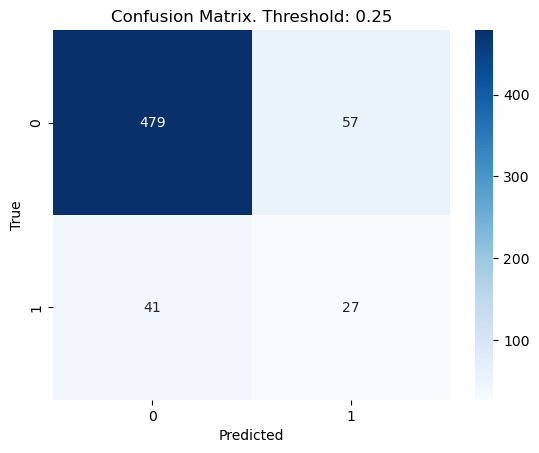

              precision    recall  f1-score   support

           0      0.921     0.894     0.907       536
           1      0.321     0.397     0.355        68

    accuracy                          0.838       604
   macro avg      0.621     0.645     0.631       604
weighted avg      0.854     0.838     0.845       604


Threshold checked: 0.3



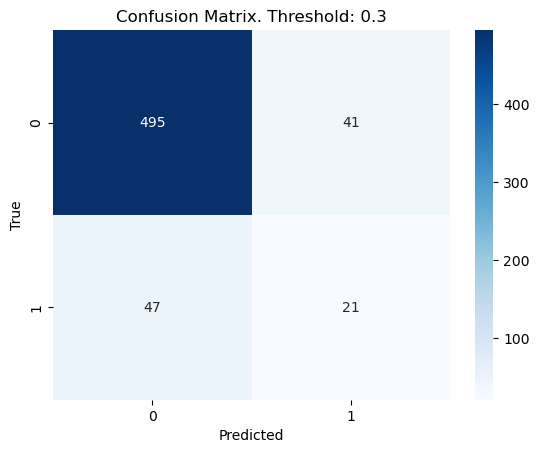

              precision    recall  f1-score   support

           0      0.913     0.924     0.918       536
           1      0.339     0.309     0.323        68

    accuracy                          0.854       604
   macro avg      0.626     0.616     0.621       604
weighted avg      0.849     0.854     0.851       604


Threshold checked: 0.35



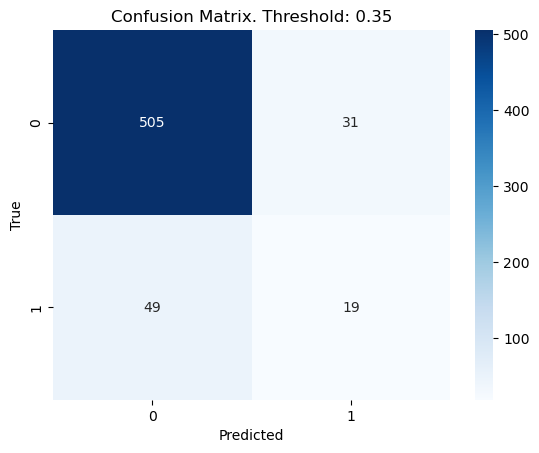

              precision    recall  f1-score   support

           0      0.912     0.942     0.927       536
           1      0.380     0.279     0.322        68

    accuracy                          0.868       604
   macro avg      0.646     0.611     0.624       604
weighted avg      0.852     0.868     0.859       604


Threshold checked: 0.4



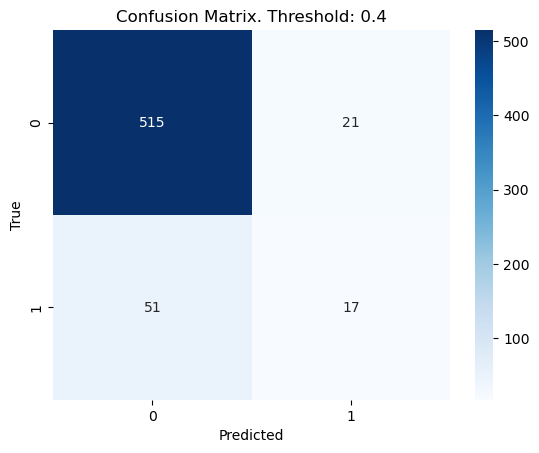

              precision    recall  f1-score   support

           0      0.910     0.961     0.935       536
           1      0.447     0.250     0.321        68

    accuracy                          0.881       604
   macro avg      0.679     0.605     0.628       604
weighted avg      0.858     0.881     0.866       604


Threshold checked: 0.45



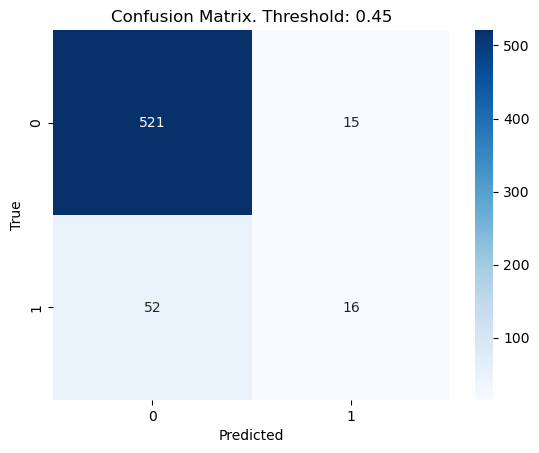

              precision    recall  f1-score   support

           0      0.909     0.972     0.940       536
           1      0.516     0.235     0.323        68

    accuracy                          0.889       604
   macro avg      0.713     0.604     0.631       604
weighted avg      0.865     0.889     0.870       604


Threshold checked: 0.5



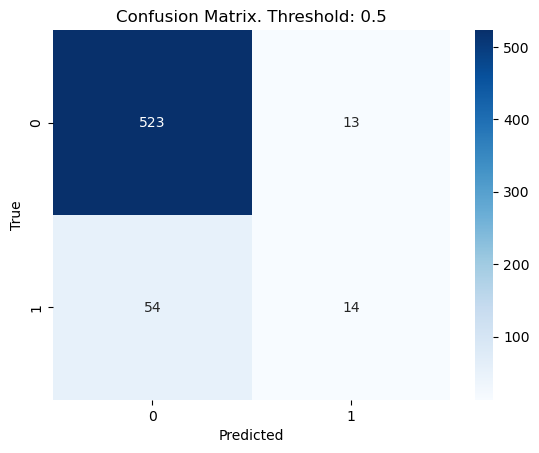

              precision    recall  f1-score   support

           0      0.906     0.976     0.940       536
           1      0.519     0.206     0.295        68

    accuracy                          0.889       604
   macro avg      0.712     0.591     0.617       604
weighted avg      0.863     0.889     0.867       604


Threshold checked: 0.55



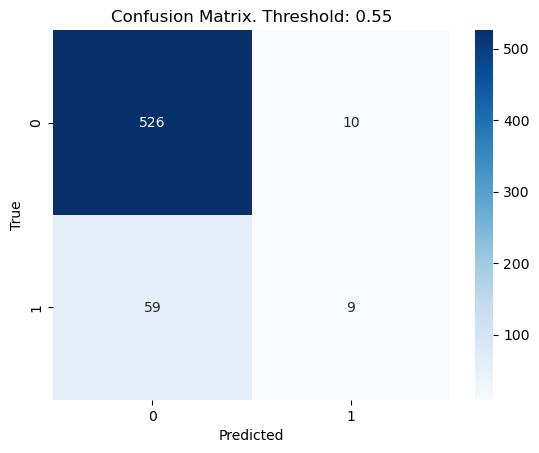

              precision    recall  f1-score   support

           0      0.899     0.981     0.938       536
           1      0.474     0.132     0.207        68

    accuracy                          0.886       604
   macro avg      0.686     0.557     0.573       604
weighted avg      0.851     0.886     0.856       604



In [29]:

y_prob_opt_thr = clf_best.predict_proba(X_val2)[:, 1]



# 1. ROC AUC
auc_score = roc_auc_score(y_val, y_prob_opt_thr)
print(f"ROC AUC: {auc_score:.3f}")

# 2. Wykres ROC
fpr, tpr, thresholds = roc_curve(y_val, y_prob_opt_thr)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve best parameters')
plt.legend()
plt.grid(True)
plt.show()

thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55]

for thr in thresholds:
    y_pred_opt_thr = (y_prob_opt_thr >= thr).astype(int)
    
    print(f'\nThreshold checked: {thr}\n')
    # 3. Confusion matrix
    cm = confusion_matrix(y_val, y_pred_opt_thr)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix. Threshold: {thr}')
    plt.show()

    # 4. Classification report
    print(classification_report(y_val, y_pred_opt_thr, digits=3))


ostateczny test na zbiorze walidacyjnym

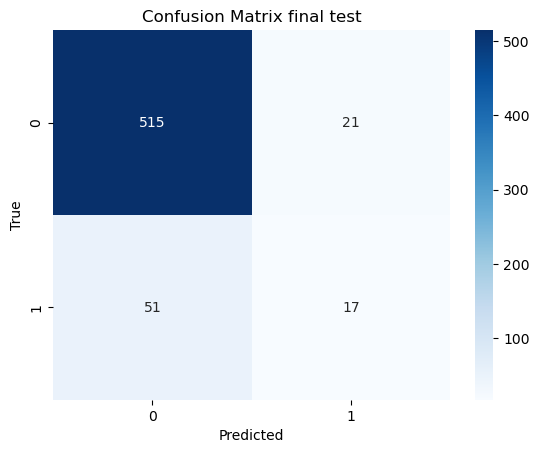

              precision    recall  f1-score   support

           0      0.910     0.961     0.935       536
           1      0.447     0.250     0.321        68

    accuracy                          0.881       604
   macro avg      0.679     0.605     0.628       604
weighted avg      0.858     0.881     0.866       604

ROC AUC: 0.781


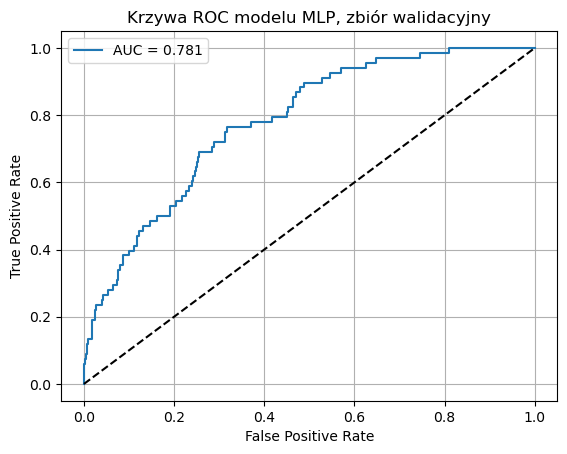

In [19]:
y_prob_best = clf_best.predict_proba(X_val2)[:, 1]
y_pred_best = (y_prob_best >= 0.4).astype(int)

cm = confusion_matrix(y_val, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix final test')
plt.show()

# 2. Classification report
print(classification_report(y_val, y_pred_best, digits=3))

# 3. ROC AUC
auc_score = roc_auc_score(y_val, y_prob_best)
print(f"ROC AUC: {auc_score:.3f}")

# 4. Wykres ROC
fpr, tpr, thresholds = roc_curve(y_val, y_prob_best)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Krzywa ROC modelu MLP, zbiór walidacyjny')
plt.legend()
plt.grid(True)
plt.show()

Poprawka - jeśli tylko jeden z 2 wierszy jest zaklasyfikowany jako niespodzianka to drugi też dostaje 1 

In [20]:
df_benchmark_val = deepcopy(df_benchmark.loc[X_val2.index])
df_benchmark_val 
df_benchmark_val['match_id'] = df_benchmark_val.apply(lambda row: 
    row['team'] + '_' + row['opponent'] + '_' +  str(row['gameweek']) + '_' +  row['season'] 
    if row['home_game'] == 1 else
    row['opponent'] + '_' + row['team'] + '_' +  str(row['gameweek']) + '_' +  row['season']
    , axis=1)
df_benchmark_val['predicted_value'] = y_pred_best

df_benchmark_val['predicted_value_corr'] = df_benchmark_val.groupby('match_id')['predicted_value'].transform('max').astype(int)
# df_benchmark_val.loc[(df_benchmark_val['prob_unexpected_result'] == 1) | (df_benchmark_val['predicted_value'] == 1),  ['season', 'gameweek', 'team', 'opponent', 'match_id', 'goals_scored', 'goals_conceded','prob_unexpected_result', 'predicted_value', 'predicted_value_corr']]
df_benchmark_val.loc[(df_benchmark_val['predicted_value'] != df_benchmark_val['predicted_value_corr']),  ['season', 'gameweek', 'team', 'opponent', 'match_id', 'goals_scored', 'goals_conceded','prob_unexpected_result', 'predicted_value', 'predicted_value_corr']]


Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


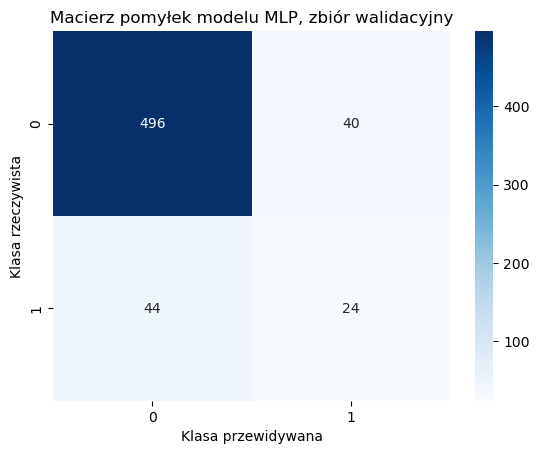

              precision    recall  f1-score   support

           0      0.919     0.925     0.922       536
           1      0.375     0.353     0.364        68

    accuracy                          0.861       604
   macro avg      0.647     0.639     0.643       604
weighted avg      0.857     0.861     0.859       604



In [26]:
cm = confusion_matrix(y_val, df_benchmark_val['predicted_value_corr'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Klasa przewidywana')
plt.ylabel('Klasa rzeczywista')
plt.title(f'Macierz pomyłek modelu MLP, zbiór walidacyjny')
plt.show()

# 2. Classification report
print(classification_report(y_val, df_benchmark_val['predicted_value_corr'], digits=3))

test na zbiorze testowym

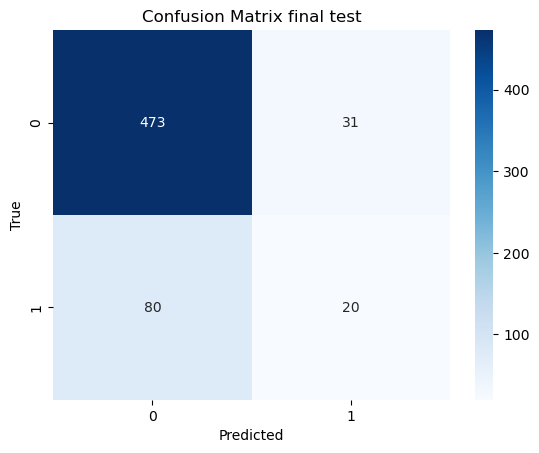

              precision    recall  f1-score   support

           0      0.855     0.938     0.895       504
           1      0.392     0.200     0.265       100

    accuracy                          0.816       604
   macro avg      0.624     0.569     0.580       604
weighted avg      0.779     0.816     0.791       604

ROC AUC: 0.716


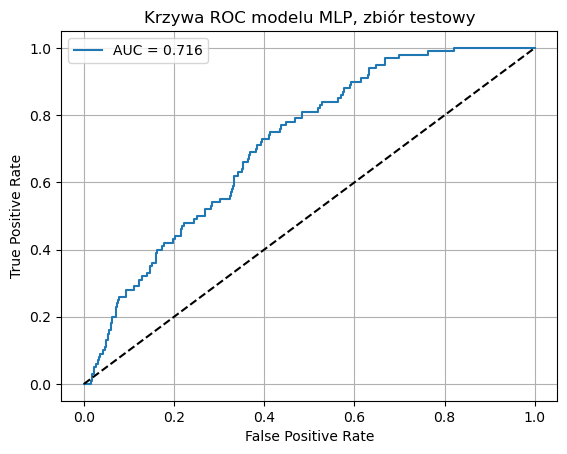

In [24]:
y_prob_the_best_test = clf_best.predict_proba(X_test2)[:, 1]
y_pred_the_best_test = (y_prob_the_best_test >= 0.4).astype(int)

cm = confusion_matrix(y_test, y_pred_the_best_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix final test')
plt.show()

# 2. Classification report
print(classification_report(y_test, y_pred_the_best_test, digits=3))

# 3. ROC AUC
auc_score = roc_auc_score(y_test, y_prob_the_best_test)
print(f"ROC AUC: {auc_score:.3f}")

# 4. Wykres ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_the_best_test)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Krzywa ROC modelu MLP, zbiór testowy')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
df_benchmark_test_final = deepcopy(df_benchmark.loc[X_test2.index])
df_benchmark_test_final
df_benchmark_test_final['match_id'] = df_benchmark_test_final.apply(lambda row: 
    row['team'] + '_' + row['opponent'] + '_' +  str(row['gameweek']) + '_' +  row['season'] 
    if row['home_game'] == 1 else
    row['opponent'] + '_' + row['team'] + '_' +  str(row['gameweek']) + '_' +  row['season']
    , axis=1)
df_benchmark_test_final['predicted_value'] = y_pred_the_best_test 
df_benchmark_test_final['predicted_value_corr'] = df_benchmark_test_final.groupby('match_id')['predicted_value'].transform('max').astype(int)
# df_benchmark_test_final.loc[(df_benchmark_test_final['prob_unexpected_result'] == 1) | (df_benchmark_test_final['predicted_value'] == 1),  ['season', 'gameweek', 'team', 'opponent', 'match_id', 'goals_scored', 'goals_conceded','prob_unexpected_result', 'predicted_value', 'predicted_value_corr']]
df_benchmark_test_final.loc[(df_benchmark_test_final['predicted_value'] != df_benchmark_test_final['predicted_value_corr']),  ['season', 'gameweek', 'team', 'opponent', 'match_id', 'goals_scored', 'goals_conceded','prob_unexpected_result', 'predicted_value', 'predicted_value_corr']]


Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


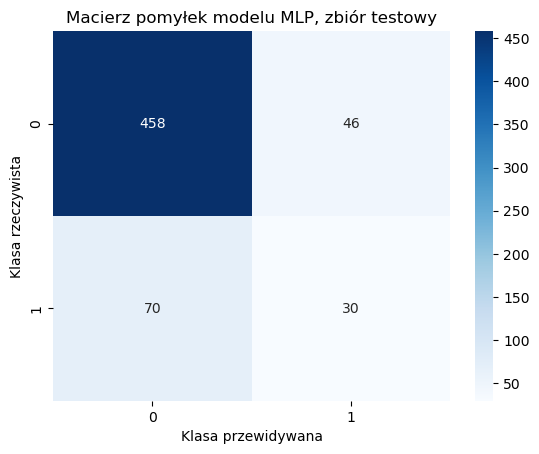

              precision    recall  f1-score   support

           0      0.867     0.909     0.888       504
           1      0.395     0.300     0.341       100

    accuracy                          0.808       604
   macro avg      0.631     0.604     0.614       604
weighted avg      0.789     0.808     0.797       604



In [27]:
cm = confusion_matrix(y_test, df_benchmark_test_final['predicted_value_corr'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Klasa przewidywana')
plt.ylabel('Klasa rzeczywista')
plt.title(f'Macierz pomyłek modelu MLP, zbiór testowy')
plt.show()

# 2. Classification report
print(classification_report(y_test, df_benchmark_test_final['predicted_value_corr'], digits=3))